In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import readrbdata

In [ ]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15
figsize = (8,6)
bigfig = (18,12)


In [3]:
# Fabry-Perot Calibration Model of the form

def fabry_time_to_freq(t, a: float, b: float, c: float, d: float, e: float):
    # print(a, b, c, d, e)
    return np.array(a + b*t + c* t**2 + d* t**3 + e * t**4)


def read_scope_csv(filepath):
    # First pass: read header to get vertical scale
    vertical_scale = None
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if "Vertical Scale" in line:
                vertical_scale = float(line.strip().split(',')[1])
            if line.startswith("TIME"):
                header_line = i
                break

    if vertical_scale is None:
        raise ValueError("Vertical Scale not found in file")

    # Second pass: read actual data
    df = pd.read_csv(filepath, skiprows=header_line)

    # Scale the Y column (assumes second column is the signal)
    y_col = df.columns[1]
    df[y_col] = df[y_col] / vertical_scale

    return df

In [4]:
# # Load in all the data
name_dict = {
    "sat":{
        "mag":{
            "scan": "SatMagCh1Scan",
            "fabry": "SatMagCh2FabryPerot",
            "signal": "SatMagCh4Signal"
        },
        "nomag":{
            "scan": "SatCh1Scan",
            "fabry": "SatCh2FabryPerot",
            "signal": "SatCh4Signal"
        }
    },
    "unsat":{
        "mag":{
            "scan": "UnSatMagCh1Scan",
            "fabry": "UnSatMagCh2FabryPerot",
            "signal": "UnSatMagCh4Signal"
        },
        "nomag":{
            "scan": "UnSatCh1Scan",
            "fabry": "UnSatCh2FabryPerot",
            "signal": "UnSatCh4Signal"
        }
    }
}

# load and reformat data


data_dict = {}
for sat_type in ["saturated", "unsaturated"]:
    data_dict[sat_type]={}
    for mag_stat in ["magnet", "no_magnet"]:
        data_dict[sat_type][mag_stat]={}
        fab_fit_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/theta.npy"
        fab_cov_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/X.npy"
        data_dict[sat_type][mag_stat]["fab_fit"]=np.load(fab_fit_filename)
        data_dict[sat_type][mag_stat]["fab_cov"]=np.load(fab_cov_filename)

        dfs = []
        for dat_type in ["signal_gen", "fabry_perot", "data"]:
            filename = f"./data/{sat_type}/{mag_stat}/{dat_type}.CSV"
            df = read_scope_csv(filename)
            df = df.rename(columns={df.columns[0]: "time", df.columns[1]: dat_type})
            dfs.append(df.set_index("time"))
            # data_dict[sat_type][mag_stat][dat_type]=df
        merged_df = pd.concat(dfs, axis=1).reset_index()

        t = np.array(merged_df["time"])
        params = data_dict[sat_type][mag_stat]["fab_fit"]
        b_fit = fabry_time_to_freq(t, *params)
        merged_df["freq"]=b_fit
        data_dict[sat_type][mag_stat]["data"]=merged_df
        # print(merged_df)

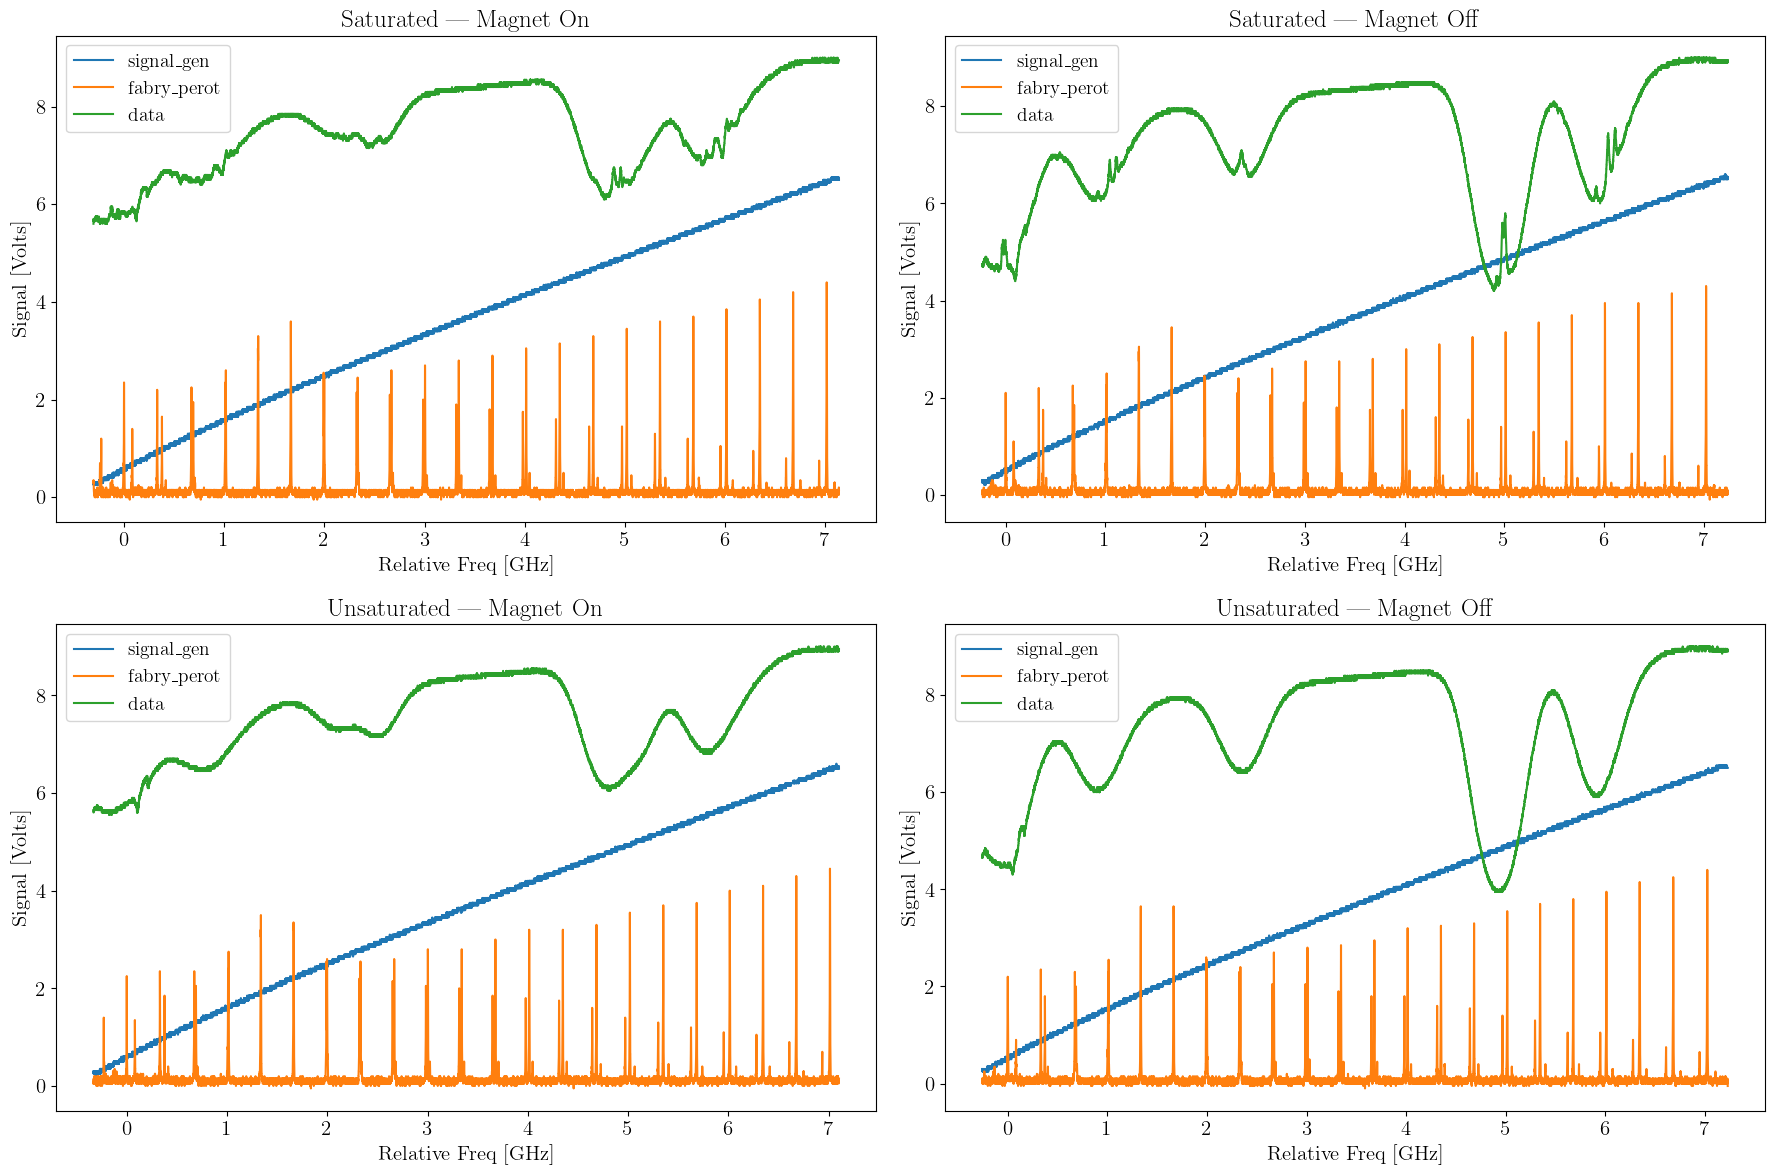

In [5]:
trim_start=3400
trim_stop=16770

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()  # easier indexing
subplot_idx = 0

for sat_type in data_dict.keys():
    for mag_stat in data_dict[sat_type].keys():
        ax = axes[subplot_idx]
        data_dfs = []
        df = data_dict[sat_type][mag_stat]["data"]
        for col in ["signal_gen", "fabry_perot", "data"]:
            ax.plot(df["freq"][trim_start:trim_stop], df[col][trim_start:trim_stop], label=col)

        ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
        ax.set_xlabel("Relative Freq [GHz]")
        ax.set_ylabel("Signal [Volts]")
        ax.legend(fontsize=14)
        
        subplot_idx += 1

plt.tight_layout()
plt.savefig("DataSummary.png")
plt.show()

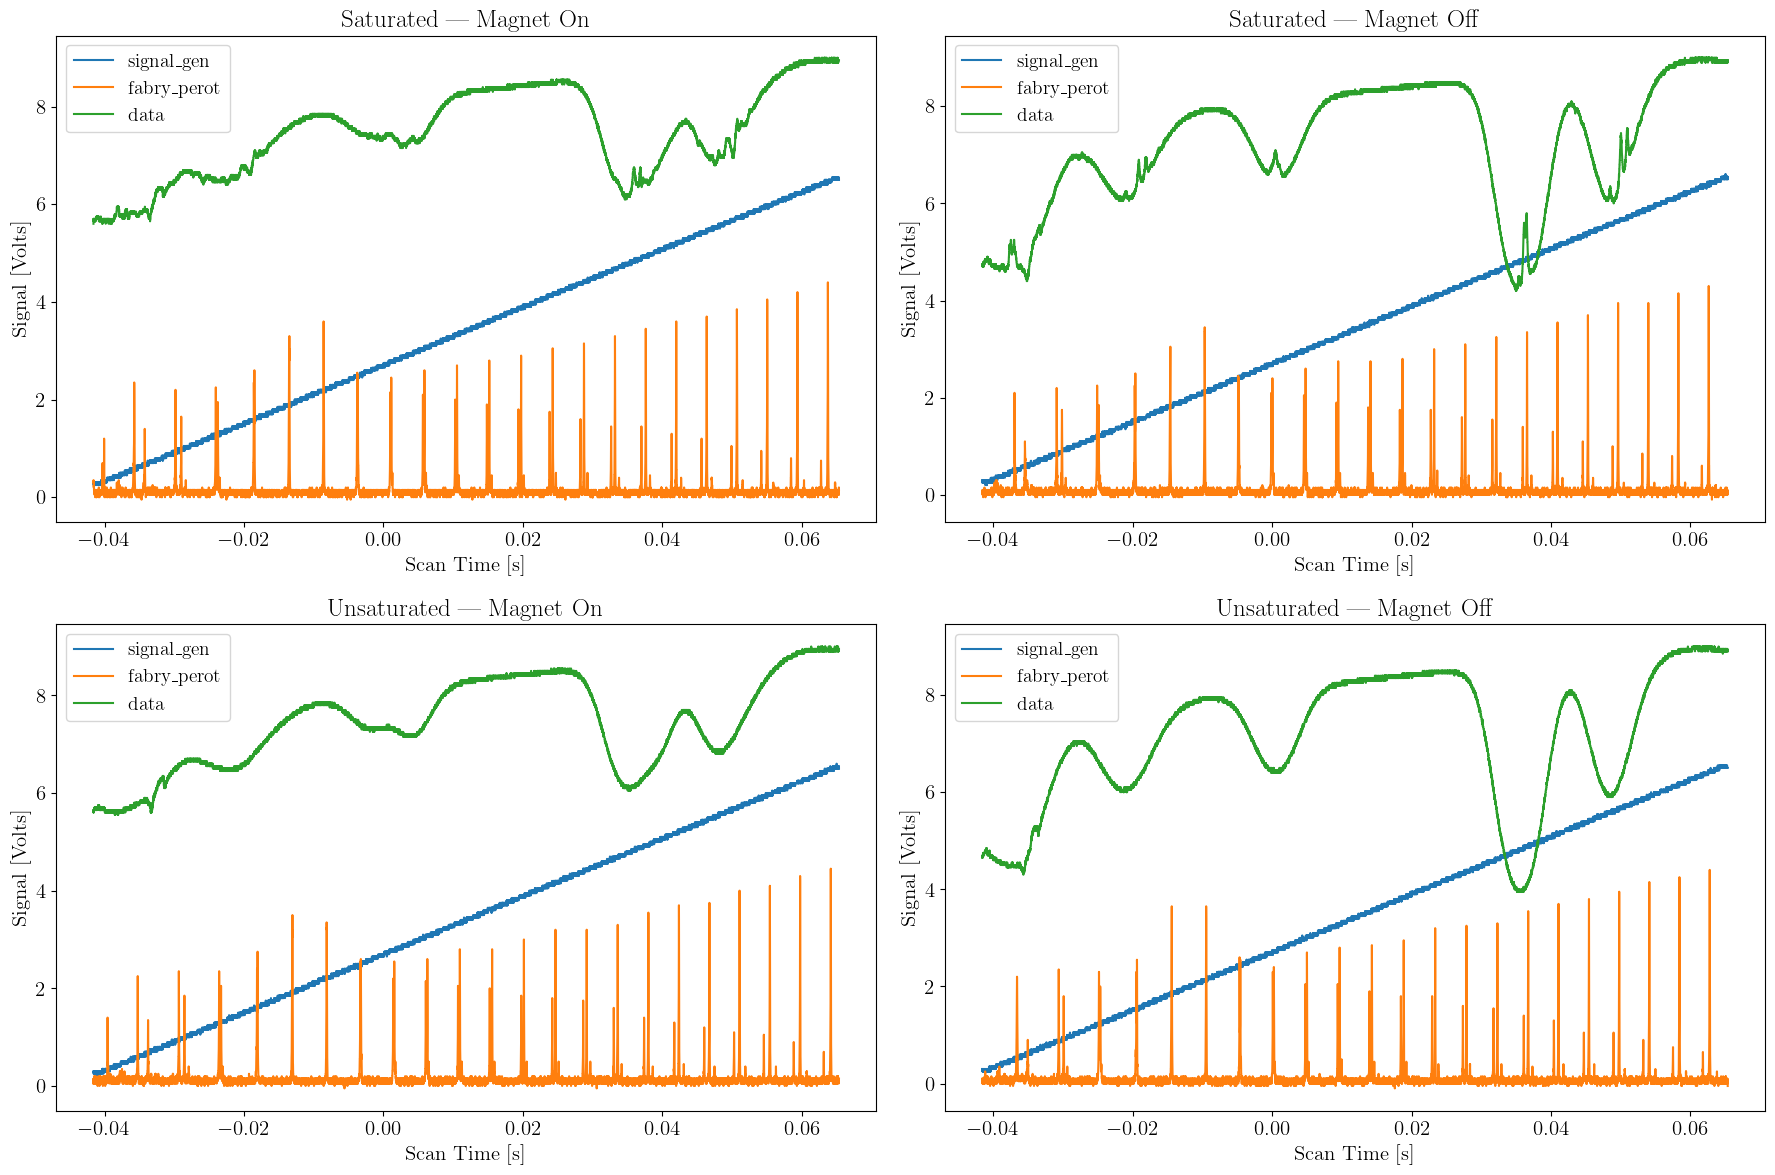

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=figsize)
axes = axes.flatten()  # easier indexing

subplot_idx = 0

for sat_type in data_dict.keys():
    for mag_stat in data_dict[sat_type].keys():
        ax = axes[subplot_idx]
        data_dfs = []
        df = data_dict[sat_type][mag_stat]["data"]
        for col in ["signal_gen", "fabry_perot", "data"]:
            ax.plot(df["time"][trim_start:trim_stop], df[col][trim_start:trim_stop], label=col)

        ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
        ax.set_xlabel("Scan Time [s]")
        ax.set_ylabel("Signal [Volts]")
        ax.legend(fontsize=14)
        
        subplot_idx += 1

plt.tight_layout()
plt.savefig("DataSummaryTime.png")
plt.show()

In [ ]:
# fig, axes = plt.subplots(2, 2, figsize=figsize)
# axes = axes.flatten()  # easier indexing

# subplot_idx = 0

# for sat_type in data_dict.keys():
#     for mag_stat in data_dict[sat_type].keys():
#         ax = axes[subplot_idx]
#         for dat_type in data_dict[sat_type][mag_stat].keys():
#             if dat_type=="fab_fit" or dat_type=="fab_cov" or dat_type=="fabry_perot":
#                 continue
#             df = data_dict[sat_type][mag_stat][dat_type]
#             # assuming columns are named 'time' and 'signal'
#             ax.plot(fabry_time_to_freq(np.asarray(df.iloc[:, 0]), *data_dict[sat_type][mag_stat]["fab_fit"]), df.iloc[:, 1], label=dat_type)
        
#         ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
#         ax.set_xlabel("Relative Freq [GHz]")
#         ax.set_ylabel("Signal [Volts]")
#         ax.legend(fontsize=10)
        
#         subplot_idx += 1

# plt.tight_layout()
# plt.savefig("DataSummary.png")
# plt.show()

In [8]:
# fit this first to remove the curve in the data so that the multi-gaussian fit can be used
def laser_amp_curve_model(x, a, b, c):
    return  a * (x)**b  + c

def laser_amp_curve_model2(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

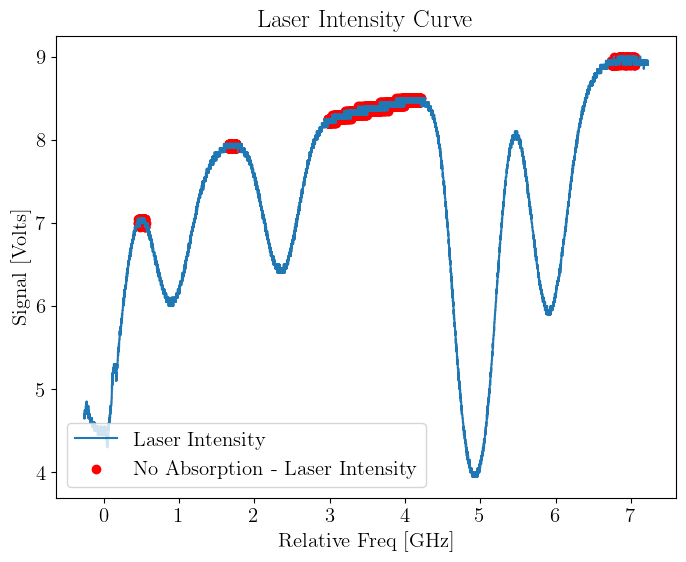

In [ ]:
plt.figure(figsize=figsize)
# plt.scatter(data_dict["unsaturated"]["no_magnet"]["data"]["freq"][trim_start:trim_stop], data_dict["unsaturated"]["no_magnet"]["data"]["data"][trim_start:trim_stop], 
#                                s=.1, alpha=.2, c="purple", label="Data")

freqs = np.array(data_dict["unsaturated"]["no_magnet"]["data"]["freq"][trim_start:trim_stop])
signal = np.array(data_dict["unsaturated"]["no_magnet"]["data"]["data"][trim_start:trim_stop])

centers=[2750, 5800, 8500, 13000]
window_sizes=[1700, 3000, 3900, 3000]

xdata_chunks = []
ydata_chunks = []

centers2=[1750, 4100, 7400, 12850]
window_sizes2=[200, 200, 2100, 500]
for i in range (4):
    start=centers2[i] - int (window_sizes2[i]/2)
    stop=centers2[i] + int (window_sizes2[i]/2)

    xdata_chunks.append(freqs[start:stop])
    ydata_chunks.append(signal[start:stop])

power_curve_x = np.concat(xdata_chunks)
power_curve_y = np.concat(ydata_chunks)

plt.plot(freqs, signal)
plt.scatter(power_curve_x, power_curve_y, c="red")
plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.title("Laser Intensity Curve")
plt.legend(["Laser Intensity", "No Absorption - Laser Intensity"])
plt.savefig("LaserIntensity.png")
plt.show()

/tmp/ipykernel_9277/1234091652.py:3: RuntimeWarning: invalid value encountered in power
  return  a * (x-x0)**b  + c
/tmp/ipykernel_9277/1234091652.py:6: RuntimeWarning: invalid value encountered in power
  return a * x ** b + c


params: [0.40652098 1.22612551 0.36558902 6.50920397]


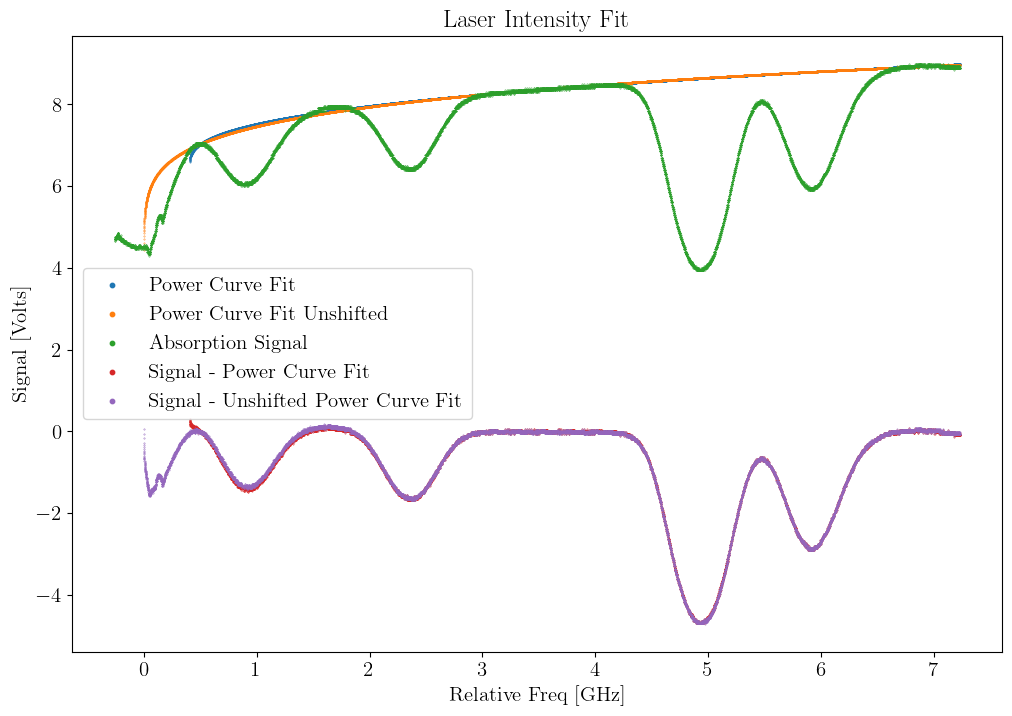

In [ ]:
# fit this first to remove the curve in the data so that the multi-gaussian fit can be used
def laser_amp_curve_model(x, x0, a, b, c):
    return  a * (x-x0)**b  + c

def laser_amp_curve_model_fixed(x, a, b, c):
    return a * x ** b + c

def laser_amp_curve_model2(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

def linear(x, a, b):
    return a*x+b

def quad(x, a, b, c):
    return a * x **2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x **3 + b * x **2 + c * x + d


# Optimize intensity curve
x0_guess=0
a_guess = 1.5
b_guess = .2
c_guess = 2
d_guess = 7

p0 = [x0_guess, a_guess, b_guess, c_guess]
p1 = [a_guess, b_guess, c_guess]

las_int_popt, las_int_pcov = scipy.optimize.curve_fit(
    laser_amp_curve_model,
    power_curve_x,
    power_curve_y,
    p0=p0,
    maxfev=100000
)

las_int_popt2, las_int_pcov2 = scipy.optimize.curve_fit(
    laser_amp_curve_model_fixed,
    power_curve_x,
    power_curve_y,
    p0=p1,
    maxfev=100000
)

print(f"params: {las_int_popt}")

power_curve_fit1 = laser_amp_curve_model(freqs, *las_int_popt)
power_curve_fit2 = laser_amp_curve_model_fixed(freqs, *las_int_popt2)
plt.figure(figsize=figsize)
plt.title("Laser Intensity Fit")
plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.scatter(freqs, power_curve_fit1,s=.1,label="Power Curve Fit")
plt.scatter(freqs, power_curve_fit2,s=.1,label="Power Curve Fit Unshifted")
plt.scatter(freqs, signal,s=.1,label="Absorption Signal")
plt.scatter(freqs, signal-power_curve_fit1,s=.1,label="Signal - Power Curve Fit")
plt.scatter(freqs, signal - power_curve_fit2,s=.1,label="Signal - Unshifted Power Curve Fit")
plt.legend(markerscale=10)
plt.savefig("LaserIntensityFit.png")
plt.show()


freq centers are at: [np.float64(0.25312467272621003), np.float64(1.6018120602890955), np.float64(3.9413814924576647), np.float64(5.140712679492433)]
signal values at previous centers are: [np.float64(5.95), np.float64(7.9), np.float64(8.45), np.float64(5.2)]
p0: [np.float64(0.5723839164408165), np.float64(0.5723839164408165), 7]
Fit Params: [ 0.92964236 -1.44276765 12.08832573]
perr: [0.00030267 0.00184483 0.03897537]
p0: [np.float64(1.8652232815116858), np.float64(1.8652232815116858), 7]
Fit Params: [ 2.36240942 -1.68438255 10.58212149]
perr: [0.0002308  0.00155113 0.02286054]
p0: [np.float64(4.379132056978401), np.float64(4.379132056978401), 7]
Fit Params: [ 4.93048583 -4.81363362  8.05209157]
perr: [0.00029052 0.00477618 0.02088257]
p0: [np.float64(5.5573592667057445), np.float64(5.5573592667057445), 7]
Fit Params: [ 5.91734629 -2.85920706  8.91944263]
perr: [0.00014335 0.0014365  0.01192119]


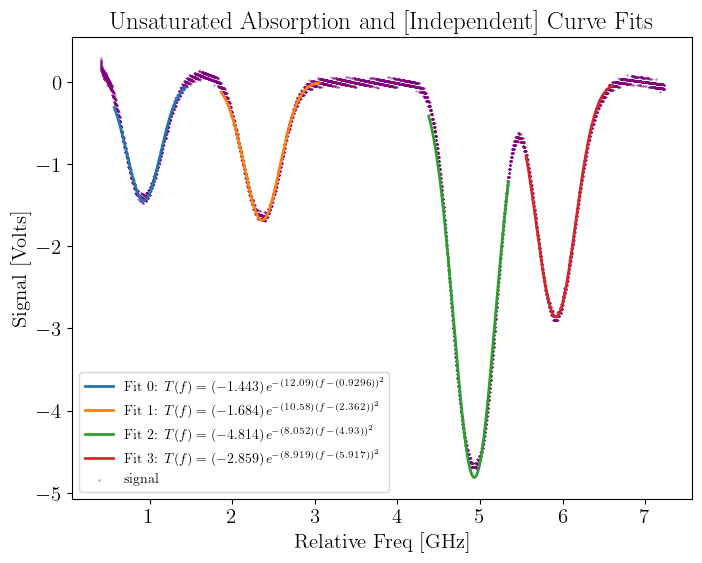

In [11]:
# For each dip, try to fit it with a gaussian of the form
def gauss_linear(x, x0, a, b):
    return a * np.exp(-b*(x-x0)**2)

centers=[1200, 3900, 8000, 10000]
window_sizes=[1700, 2100, 1600, 1700]

def trim_leading_nans(x, y):
    first_valid = np.argmax(~np.isnan(y))
    return x[first_valid:], y[first_valid:]

print(f"freq centers are at: {[freqs[centers[i]] for i in range(len(centers))]}")
print(f"signal values at previous centers are: {[signal[centers[i]] for i in range(len(centers))]}")

xtrim, ytrim = trim_leading_nans(freqs, signal-power_curve_fit1)

fits=[]
plt.figure(figsize=(8,6))
for i, center in enumerate(centers):
    
    start = center - int ( window_sizes[i]/2)
    stop = center + int( window_sizes[i]/2)

    di_x = xtrim[start:stop]
    di_y = ytrim[start:stop]

    # xdata = xdata[1000:]
    # ydata = ydata[1000:]

    #  model: a * np.exp(-b * (x - x0)**2) + c * x + d
    x0_guess = di_x[np.argmin(di_x)]
    a_guess = np.min(di_x)
    b_guess = 7
    # c_guess = 0.05

    p0 = [x0_guess, a_guess, b_guess]
    print(f"p0: {p0}")


    dipopt, dipcov = scipy.optimize.curve_fit(
        gauss_linear,
        di_x,
        di_y,
        p0=p0,
        #bounds=bounds,
        maxfev=200000
    )

    print(f"Fit Params: {dipopt}")
    fits.append((dipopt, dipcov))

    # fitted parameters
    x0_fit, a_fit, b_fit = dipopt

    # uncertainties (standard deviation of parameters)
    confidence_interval_95 = np.sqrt(np.diag(dipcov))
    print(f"perr: {confidence_interval_95}")

    # helper for 4 significant figures
    def fmt(x):
        return f"{x:.4g}"

    # formatted model string
    model_str = (
        r"$T(f) = ("
        + f"{fmt(a_fit)}"
        + r")\,e^{{\!-("
        + f"{fmt(b_fit)}"
        + r")\,(f - ("
        + f"{fmt(x0_fit)}"
        + r"))^2}}"
        + r"$"
    )

    # print(f"Peak {i+1} fit:")
    # print(model_str)

    # plot the fitted curve, but plot it for the full data range to make sure it's reasonable
    xfit = np.linspace(di_x.min(), di_x.max(), 2000)
    yfit = gauss_linear(xfit, *dipopt)
    plt.plot(xfit, yfit, linewidth=2, label=f"Fit {i}: {model_str}")
plt.scatter(xtrim, ytrim,s=.1,c="purple", label="signal")

plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.title("Unsaturated Absorption and [Independent] Curve Fits")
plt.legend(fontsize=10)
# plt.savefig("DopplerFits.png")
plt.show()

[np.float64(0.9996912850304315), np.float64(2.6582852572663005), np.float64(4.2387712487027525), np.float64(6.08827382172068)]
[np.float64(6.2), np.float64(7.5), np.float64(8.5), np.float64(6.65)]
p0: [-2, 1, 0.7, -2, 2.3, 0.7, -4, 5, 0.7, -3, 6, 0.7]


/tmp/ipykernel_9277/3879817981.py:2: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1*(x-x1)**2) + a2 * np.exp(-b2*(x-x2)**2) + a3 * np.exp(-b3*(x-x3)**2) + a4 * np.exp(-b4*(x-x4)**2)


Fit Params: [-1.45617025  0.93145316 12.7148169  -1.69071449  2.36315835 10.77180675
 -4.84617974  4.92768028  8.4111436  -2.8879249   5.92453554  9.69660978]


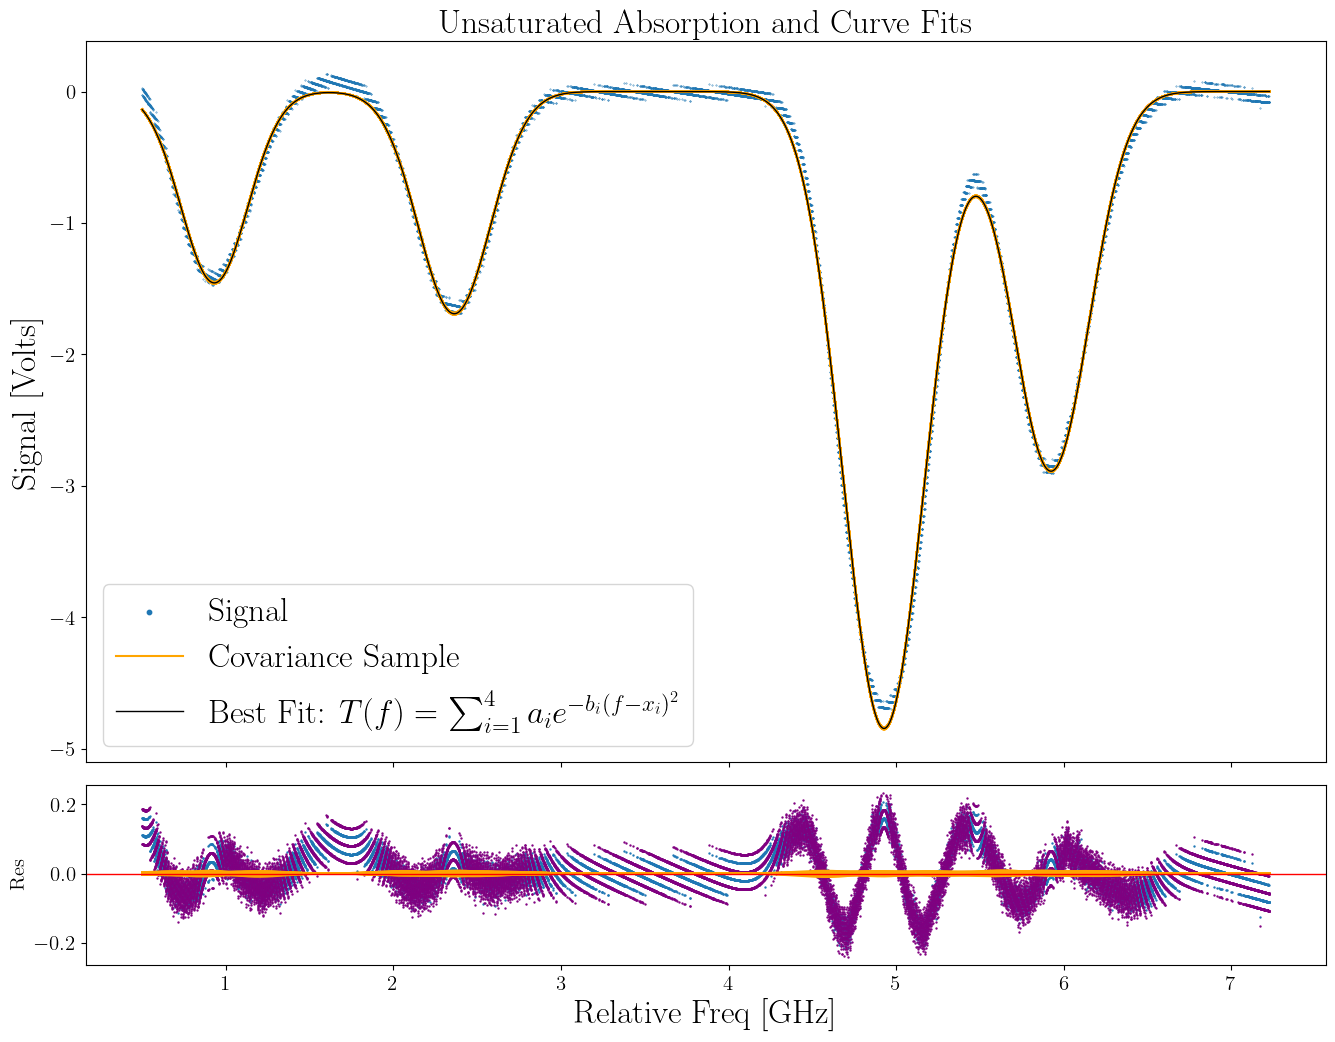


Fit 1:
    a1 = -1.456 ± 0.0059
    x1 = 0.9315 ± 0.00092
    b1 = 12.71 ± 0.12
    a2 = -1.691 ± 0.0059
    x2 = 2.363 ± 0.00087
    b2 = 10.77 ± 0.087
    a3 = -4.846 ± 0.0058
    x3 = 4.928 ± 0.00034
    b3 = 8.411 ± 0.024
    a4 = -2.888 ± 0.0061
    x4 = 5.925 ± 0.00056
    b4 = 9.697 ± 0.049


In [ ]:
def absorption_model(x, a1, x1, b1, a2, x2, b2, a3, x3, b3, a4, x4, b4):
    return a1 * np.exp(-b1*(x-x1)**2) + a2 * np.exp(-b2*(x-x2)**2) + a3 * np.exp(-b3*(x-x3)**2) + a4 * np.exp(-b4*(x-x4)**2)

full_fits = []

def print_fits(fits, param_names=None):
    import numpy as np

    for i, (popt, pcov) in enumerate(fits):
        perr = 2*np.sqrt(np.diag(pcov))

        print(f"\nFit {i+1}:")

        for j, (val, err) in enumerate(zip(popt, perr)):
            name = param_names[j] if param_names else f"p{j}"
            print(f"  {name:>4} = {val:.4g} ± {err:.2g}")

# transform data by subtracting the power curve fit

centers=[2750, 5800, 8500, 11550]
window_sizes=[1700, 3000, 3900, 1700]
trim=200

print([freqs[centers[i]] for i in range(len(centers))])
print([signal[centers[i]] for i in range(len(centers))])

def trim_leading_nans(x, y):
    first_valid = np.argmax(~np.isnan(y))
    return (x[first_valid:], y[first_valid:])

def trim_leading_messy(x, y, trim: int):
    return x[trim:], y[trim:]

doppler_x, doppler_y = trim_leading_messy(*trim_leading_nans(freqs, signal-power_curve_fit1), trim=trim)

#  model: a * np.exp(-b * (x - x0)**2) + c * x + d
a1_guess = -2
x1_guess = 1
b1_guess = .7

a2_guess = -2
x2_guess = 2.3
b2_guess = .7

a3_guess = -4
x3_guess = 5
b3_guess = .7

a4_guess = -3
x4_guess = 6
b4_guess = .7

# c_guess = -.05
# d_guess = 0

p0 = [a1_guess, x1_guess, b1_guess, a2_guess, x2_guess, b2_guess, a3_guess, x3_guess, b3_guess, a4_guess, x4_guess, b4_guess]
print(f"p0: {p0}")
# optional bounds
# bounds = (
#     [xdata.min(), -np.inf, 0, -np.inf, -np.inf],   # lower
#     [xdata.max(), 0,      np.inf, np.inf,  np.inf] # upper
# )

popt, pcov = scipy.optimize.curve_fit(
    absorption_model,
    doppler_x,
    doppler_y,
    p0=p0,
    #bounds=bounds,
    maxfev=200000
)

print(f"Fit Params: {popt}")
full_fits.append((popt, pcov))

# unpack parameters
a1, x1, b1, a2, x2, b2, a3, x3, b3, a4, x4, b4 = popt

# uncertainties
confidence_interval_95 = 2*np.sqrt(np.diag(pcov))

# formatter
def fmt(x):
    return f"{x:.4g}"

model_str = (
    r"$T(f) = \sum_{i=1}^{4} a_i e^{-b_i(f-x_i)^2}$"
)

xfit = np.linspace(doppler_x.min(), doppler_x.max(), 2000)
yfit = absorption_model(xfit, *popt)

y_model_data = absorption_model(doppler_x, *popt)
residuals = doppler_y - y_model_data

# create stacked plots (short residual panel)
fig, (ax, ax_res) = plt.subplots(
    2, 1,
    figsize=(16,12),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
)

# main plot
ax.scatter(doppler_x, doppler_y, s=0.1, label="Signal")
# uncertainties are too small to do this
for i in range(100):
    rand_fit = absorption_model(xfit, *np.random.multivariate_normal(popt, pcov))
    ax.plot(xfit, rand_fit,c="orange", alpha=1,label=("Covariance Sample" if i==1 else None))
    ax_res.plot(xfit, rand_fit - yfit, c="orange")
ax.plot(xfit, yfit, linewidth=1, color="black", label=f"Best Fit: {model_str}")
ax.set_ylabel("Signal [Volts]",fontsize=24)
ax.set_title("Unsaturated Absorption and Curve Fits",fontsize=24)
# # residual plot
# measurement_uncertainty = 0.25
# yerr = np.full_like(residuals, measurement_uncertainty, dtype=float)

ax_res.scatter(doppler_x, residuals, s=0.5)
ax_res.scatter(doppler_x, residuals+.025,s=.5,c="purple", label="Measurement Uncertainties")
ax_res.scatter(doppler_x,residuals-.025,s=.5,c="purple")
ax_res.axhline(0, color="red", linewidth=1)
ax_res.set_xlabel("Relative Freq [GHz]",fontsize=24)
ax_res.set_ylabel("Res", fontsize)

ax.legend(markerscale=10,fontsize=24)
# ax_res.legend()

# ax_res.errorbar(
#     xdata,
#     residuals,
#     yerr=yerr,
#     fmt='.',
#     markersize=.01,
#     elinewidth=0.1,
#     capsize=2
# )
# ax_res.axhline(0, color="black", linewidth=1)
# ax_res.set_xlabel("Relative Freq [GHz]")
# ax_res.set_ylabel("Res")

# residual plot

plt.savefig("Multi-Curve Fit")
plt.show()

# # fitted curve
# xfit = np.linspace(xdata.min(), xdata.max(), 2000)
# yfit = absorption_model(xfit, *popt)
# plt.figure(figsize=(18,10))
# plt.plot(xfit, yfit, linewidth=2, label=f"Fit: {model_str}",color="Red")
# plt.scatter(xdata, ydata,s=.1)

# plt.xlabel("Relative Freq [GHz]")
# plt.ylabel("Signal [Volts]")
# plt.title("Unsaturated Absorption and Curve Fits")
# plt.legend()
# # plt.savefig("DopplerFits.png")
# plt.show()


param_names = [
    "a1","x1","b1",
    "a2","x2","b2",
    "a3","x3","b3",
    "a4","x4","b4",
    "c","d"
]

print_fits(full_fits, param_names)


The four peaks are centered at $\omega_1=.9315 \pm 9.2\times 10^{-4}, \omega_2=2.363\pm 8.7 \times 10^{-4}, \omega_3=4.928 \pm 3.4 \times 10^{-4}, \omega_4=5.925 \pm 5.6 \times 10^{-4} \text{GHz}$

$\pm$'s give two standard deviation, or a 95% confidence interval.

Let's make a guess as to what the theoretical model should predict - for a peak centered at $\omega_1=.9095$, which could either be Rubidium-85 or Rubidium-87, we would like to predict the approximate width of the peak (in GHz)


Expect absorption to be $$g(\omega)=\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Which means that the Transmittance would be the inverse:

$$T(\omega)=V_{0}-A\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Model is of the form: $A e^{-B(\omega-\omega_0)^2}+Cx+D$
calculate $B$ as $-\frac{c^2}{u^2\omega_0^2}$, which for $^{85}$ Rb, 
$-\frac{c^2}{u^2\omega_0^2}=-\frac{299792458^2}{249^2 * \omega_0^2}=-9.05$

But -9.05 is in units of gigahertz, so this should be expected to 

$$\omega_0^2 = \frac{299792458^2}{249^2*9.05} \approx 1.60174778635\times10^{11} GHz$$, or $$1.60174778635\times10^{29} [Hz]^2$$ Giving a wavelength of $\lambda = 749 [nm]$ 

In [ ]:

# Chamber temp
chamber_temp = 45.2
v_laser = 5
# scan freq
c=299792458 # m/s
k_b=1.38065e-23
T=273.15 + chamber_temp
N_a = 6.022e23
m85_amu = 84.91
m87_amu = 86.91
m85_kg = m85_amu / (N_a*1000)
m87_kg = m87_amu / (N_a*1000)

u85 = np.sqrt(2*k_b*T / m85_kg)
u87 = np.sqrt(2*k_b*T / m87_kg)
omega_0=c/750e-9
print(f"m85_kg: {m85_kg}\nu85: {u85}\nc: {c} m/s\n")
print(f"m87_kg: {m87_kg}\nu87: {u87}\nc: {c} m/s\n")

b_fits = [12.71, 10.77, 8.411, 9.697]

# Calculate Frequency based on width of each peak:

def dip_freq_ghz(b: float)->float:
    frac_base = c**2 / b
    return (np.sqrt(frac_base/(u85**2)), np.sqrt(frac_base/(u87**2)))

for i, b_fit in enumerate(b_fits):
    print(f"Peak No. {i}, b={b_fit}")
    peak_freqs = dip_freq_ghz(b_fit)

    lambda1 = c / (peak_freqs[0]*1e9)
    lambda2 = c / (peak_freqs[1]*1e9)
    print(f"\tRb85-  Wavelength: {lambda1} m\tFreq: {peak_freqs[0]} GHz")
    print(f"\tRb87 - Wavelength: {lambda2} m\tFreq: {peak_freqs[1]} GHz")

# The width of the doppler broadened distribution is somewhere in the range of several hundred megahertz. For a resonant frequency of c/750e-9, we expect to see the absorption spectrum from c/750e-9+-560MHz (FWHM)
# This translates to frequencies of between 3.997 227 173 33e14 to 3.997 238 373 33e14 Hz. 

# freq_vals = np.linspace(c/(c/750e-9-560e6), c/(c/750e-9+560e6), 1000)

m85_kg: 1.4099966788442375e-25
u85: 249.68944193979328
c: 299792458 m/s

m87_kg: 1.4432082364662901e-25
u87: 246.7997549674793
c: 299792458 m/s

Peak No. 0, b=12.71
	Rb85-  Wavelength: 8.901700002583611e-07 m	Freq: 336781.12934943754 GHz
	Rb87 - Wavelength: 8.798679521104399e-07 m	Freq: 340724.3749257166 GHz
Peak No. 1, b=10.77
	Rb85-  Wavelength: 8.194227746240228e-07 m	Freq: 365858.09826625127 GHz
	Rb87 - Wavelength: 8.099394929191465e-07 m	Freq: 370141.7953080691 GHz
Peak No. 2, b=8.411
	Rb85-  Wavelength: 7.241424302495356e-07 m	Freq: 413996.53642266634 GHz
	Rb87 - Wavelength: 7.157618398227427e-07 m	Freq: 418843.8686173087 GHz
Peak No. 3, b=9.697
	Rb85-  Wavelength: 7.775330825662299e-07 m	Freq: 385568.7490627948 GHz
	Rb87 - Wavelength: 7.685345954785117e-07 m	Freq: 390083.23081843904 GHz


In [ ]:
# Implement  in SI units
def g_d(omega, c, u, omega_0):
    scale = (c / (u * omega_0 * np.sqrt(np.pi)))
    print(scale)
    exp_scale = -c**2/(u**2)
    #print(f"Exp scale: {exp_scale}")
    exp_val = ((omega-omega_0)/omega_0)**2
    #print(f"Exp val: {exp_val}")
    exp = np.exp(- (c**2 / u**2) * ((omega - omega_0) / omega_0)**2)
    #print(f"Exp: {exp}")
    return scale*exp
print(f"Frequency of light with wavelength 750nm: {c/750e-9:.4g} Hz")
print(g_d(c/750e-9, c, u85, omega_0))


Frequency of light with wavelength 750nm: 3.997e+14 Hz
1.6946739292358545e-09
1.6946739292358545e-09
